# Network Attack Detection EDA

## 1. Title and Introduction

This notebook performs exploratory data analysis (EDA) for the `attack-lab` project.

The goal is to understand packet-level network traffic features that can help detect attacks. The dataset contains normal traffic, ping flood traffic, and SYN-like flood traffic extracted from Wireshark PCAP captures. By studying feature distributions, class balance, timing behavior, protocol usage, TCP flags, and feature correlations, we prepare the data for a machine learning model such as Random Forest.

## 2. Import Libraries

Import the core data analysis and visualization libraries.

In [2]:
# Data analysis libraries
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean seaborn style for all plots
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 3. Load Dataset

Load the cleaned dataset created by the preprocessing script and display the first few rows.

In [3]:
# Locate the dataset whether the notebook is run from project root or notebooks/
dataset_path = Path("csv/final_dataset_clean.csv")
if not dataset_path.exists():
    dataset_path = Path("../csv/final_dataset_clean.csv")

# Read the cleaned CSV dataset
df = pd.read_csv(dataset_path)

# Create clear display names for labels used in plots
label_map = {
    0: "Normal",
    1: "Ping_Flood",
    2: "SYN_Flood",
}
df["label_display"] = df["label"].map(label_map).fillna("Unknown")

# Display the first few rows
df.head()

,frame.time_epoch,ip.src,ip.dst,ip.proto,frame.len,tcp.srcport,tcp.dstport,tcp.flags.syn,tcp.flags.ack,tcp.flags.reset,ip.ttl,icmp.type,icmp.code,label,label_name,source_file,inter_arrival,label_display
0,1.776764e+09,10.10.166.245,10.10.166.129,1.0,98,0.0,0.0,0.0,0.0,0.0,64.0,8.0,0.0,0,Normal,normal.csv,0.000000,Normal
1,1.776764e+09,10.10.166.129,10.10.166.245,1.0,98,0.0,0.0,0.0,0.0,0.0,128.0,0.0,0.0,0,Normal,normal.csv,0.000309,Normal
2,1.776764e+09,10.10.166.245,10.10.166.129,1.0,98,0.0,0.0,0.0,0.0,0.0,64.0,8.0,0.0,0,Normal,normal.csv,1.023629,Normal
3,1.776764e+09,10.10.166.129,10.10.166.245,1.0,98,0.0,0.0,0.0,0.0,0.0,128.0,0.0,0.0,0,Normal,normal.csv,0.000983,Normal
4,1.776764e+09,0,0,0.0,60,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Normal,normal.csv,0.644947,Normal


## 4. Basic Dataset Information

Review the dataset shape, column names, and data types.

In [4]:
# Shape gives the number of rows and columns
print("Dataset shape:", df.shape)

# Column names show available packet-level features
print("\nColumn names:")
print(df.columns.tolist())

# Data types help identify numeric and categorical fields
print("\nData types:")
print(df.dtypes)

Dataset shape: (23685, 18)

Column names:
['frame.time_epoch', 'ip.src', 'ip.dst', 'ip.proto', 'frame.len', 'tcp.srcport', 'tcp.dstport', 'tcp.flags.syn', 'tcp.flags.ack', 'tcp.flags.reset', 'ip.ttl', 'icmp.type', 'icmp.code', 'label', 'label_name', 'source_file', 'inter_arrival', 'label_display']

Data types:
frame.time_epoch    float64
ip.src                  str
ip.dst                  str
ip.proto            float64
frame.len             int64
tcp.srcport         float64
tcp.dstport         float64
tcp.flags.syn       float64
tcp.flags.ack       float64
tcp.flags.reset     float64
ip.ttl              float64
icmp.type           float64
icmp.code           float64
label                 int64
label_name              str
source_file             str
inter_arrival       float64
label_display           str
dtype: object


## 5. Summary Statistics

Use `describe()` to summarize numeric packet features such as packet length, protocol, TCP flags, TTL, ICMP fields, and inter-arrival time.

In [5]:
# Summary statistics for numeric features
df.describe()

,frame.time_epoch,ip.proto,frame.len,tcp.srcport,tcp.dstport,tcp.flags.syn,tcp.flags.ack,tcp.flags.reset,ip.ttl,icmp.type,icmp.code,label,inter_arrival
count,2.368500e+04,23685.000000,23685.000000,23685.000000,23685.000000,23685.000000,23685.000000,23685.000000,23685.000000,23685.000000,23685.0,23685.000000,23685.000000
mean,1.776765e+09,3.322187,83.560439,10917.174330,10916.116529,0.232299,0.232721,0.232214,95.739244,2.129280,0.0,1.359257,0.036735
std,1.470875e+02,2.496970,19.472304,20271.990616,20271.489117,0.422308,0.422575,0.422254,32.343655,3.535666,0.0,0.665331,1.114000
min,1.776764e+09,0.000000,42.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
25%,1.776765e+09,1.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.000000,0.000000,0.0,1.000000,0.000568
50%,1.776765e+09,1.000000,98.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.000000,0.000000,0.0,1.000000,0.001100
75%,1.776765e+09,6.000000,98.000000,80.000000,80.000000,0.000000,0.000000,0.000000,128.000000,8.000000,0.0,2.000000,0.008955
max,1.776765e+09,6.000000,1514.000000,60998.000000,60998.000000,1.000000,1.000000,1.000000,128.000000,8.000000,0.0,2.000000,131.287305


## 6. Missing Values Analysis

Check whether any columns still contain missing values after preprocessing.

In [6]:
# Count missing values in each column
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

frame.time_epoch    0
ip.src              0
ip.dst              0
ip.proto            0
frame.len           0
tcp.srcport         0
tcp.dstport         0
tcp.flags.syn       0
tcp.flags.ack       0
tcp.flags.reset     0
ip.ttl              0
icmp.type           0
icmp.code           0
label               0
label_name          0
source_file         0
inter_arrival       0
label_display       0
dtype: int64

## 7. Class Distribution

Count packets for each traffic class and visualize the distribution.

In [7]:
# Count each class: Normal, Ping_Flood, and SYN_Flood
class_counts = (
    df["label_display"]
    .value_counts()
    .reindex(["Normal", "Ping_Flood", "SYN_Flood"], fill_value=0)
)
class_counts

label_display
Normal         2516
Ping_Flood    10144
SYN_Flood     11025
Name: count, dtype: int64

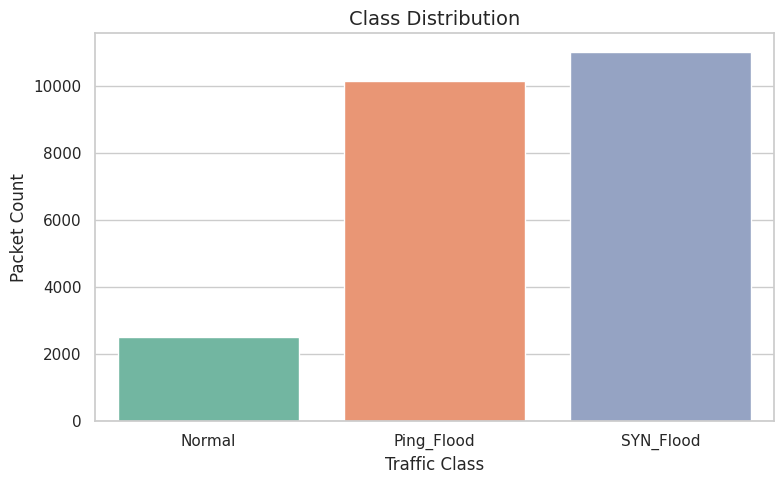

In [8]:
# Bar chart for class distribution
class_counts_df = class_counts.rename_axis("Traffic Class").reset_index(name="Packet Count")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=class_counts_df,
    x="Traffic Class",
    y="Packet Count",
    hue="Traffic Class",
    palette="Set2",
    legend=False,
)
plt.title("Class Distribution")
plt.xlabel("Traffic Class")
plt.ylabel("Packet Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Packet Length Analysis

Analyze packet size behavior using `frame.len`. Packet length can reveal differences between normal traffic and repeated attack traffic.

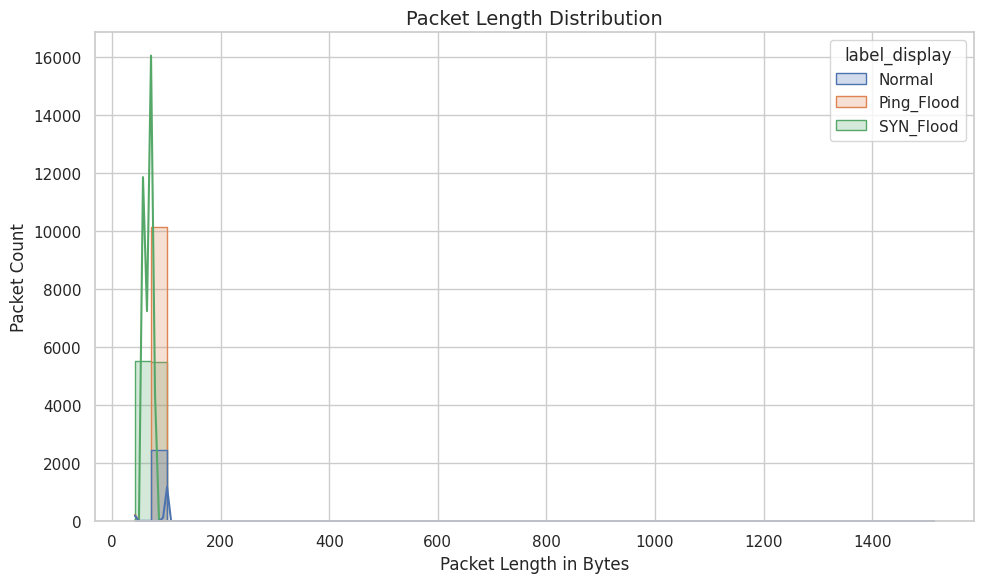

In [9]:
# Histogram of packet lengths by traffic class
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="frame.len",
    hue="label_display",
    bins=50,
    kde=True,
    element="step",
)
plt.title("Packet Length Distribution")
plt.xlabel("Packet Length in Bytes")
plt.ylabel("Packet Count")
plt.tight_layout()
plt.show()

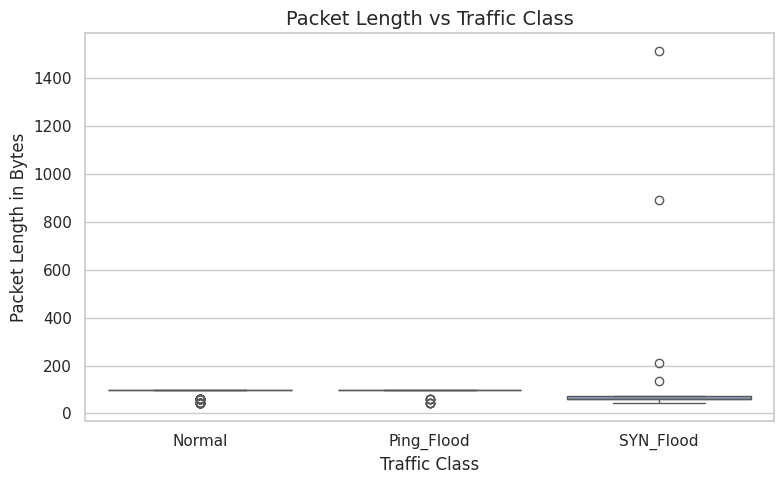

In [10]:
# Boxplot comparing packet lengths across labels
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="label_display",
    y="frame.len",
    hue="label_display",
    palette="Set2",
    legend=False,
)
plt.title("Packet Length vs Traffic Class")
plt.xlabel("Traffic Class")
plt.ylabel("Packet Length in Bytes")
plt.tight_layout()
plt.show()

## 9. Protocol Analysis

Analyze protocol usage using `ip.proto`. ICMP traffic commonly appears as protocol 1, while TCP traffic commonly appears as protocol 6.

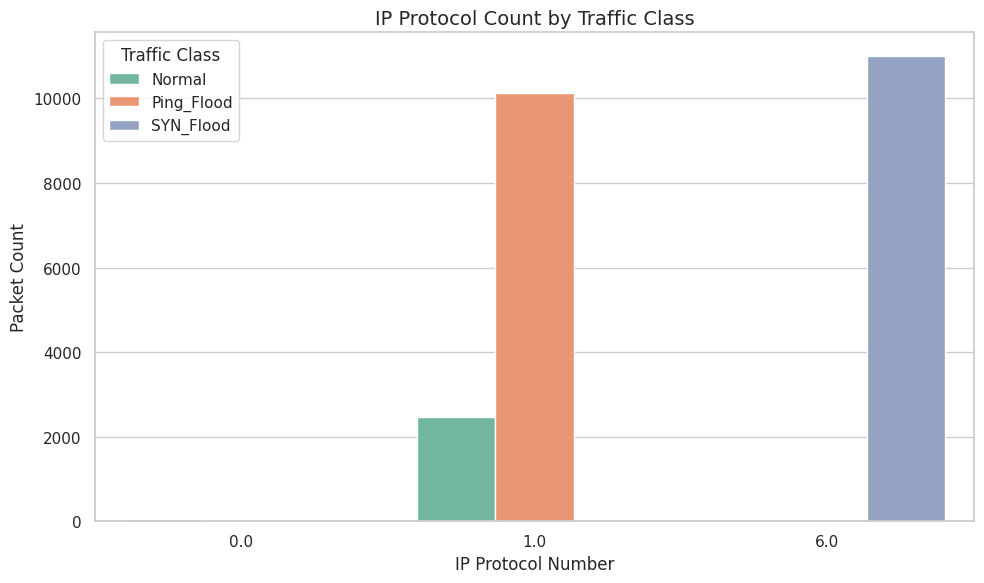

In [11]:
# Count plot of IP protocol values grouped by traffic class
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="ip.proto",
    hue="label_display",
    palette="Set2",
)
plt.title("IP Protocol Count by Traffic Class")
plt.xlabel("IP Protocol Number")
plt.ylabel("Packet Count")
plt.legend(title="Traffic Class")
plt.tight_layout()
plt.show()

## 10. TCP Flags Analysis

Analyze TCP SYN and ACK flags. SYN-heavy traffic can indicate connection initiation bursts or SYN flood-like behavior.

In [12]:
# Mean TCP flag values by traffic class
tcp_flag_summary = (
    df.groupby("label_display")[["tcp.flags.syn", "tcp.flags.ack"]]
    .mean()
    .reindex(["Normal", "Ping_Flood", "SYN_Flood"])
)
tcp_flag_summary

,tcp.flags.syn,tcp.flags.ack
label_display,,
Normal,0.000000,0.000000
Ping_Flood,0.000000,0.000000
SYN_Flood,0.499048,0.499955


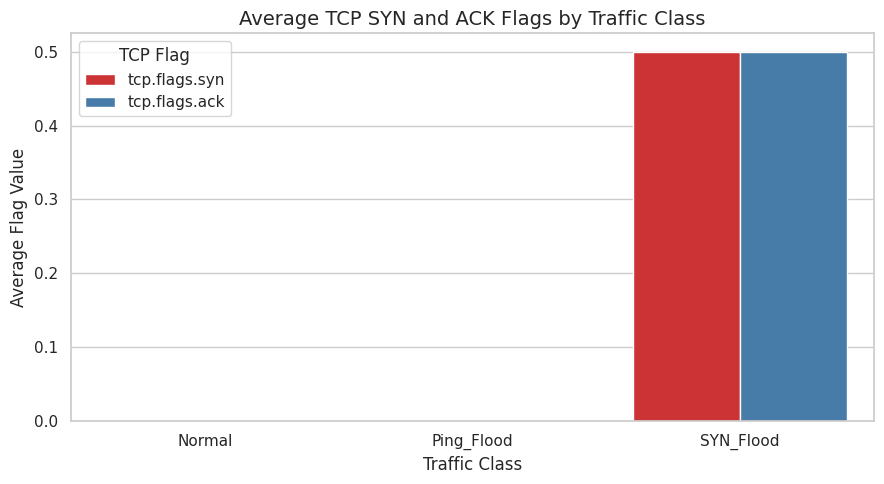

In [13]:
# Bar plot of average SYN and ACK flag activity by class
tcp_flag_plot = tcp_flag_summary.reset_index().melt(
    id_vars="label_display",
    value_vars=["tcp.flags.syn", "tcp.flags.ack"],
    var_name="TCP Flag",
    value_name="Average Value",
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=tcp_flag_plot,
    x="label_display",
    y="Average Value",
    hue="TCP Flag",
    palette="Set1",
)
plt.title("Average TCP SYN and ACK Flags by Traffic Class")
plt.xlabel("Traffic Class")
plt.ylabel("Average Flag Value")
plt.legend(title="TCP Flag")
plt.tight_layout()
plt.show()

## 11. Inter-arrival Time Analysis

Analyze `inter_arrival`, the time difference between consecutive packets. Attack traffic often has shorter and more repetitive inter-arrival times than normal traffic.

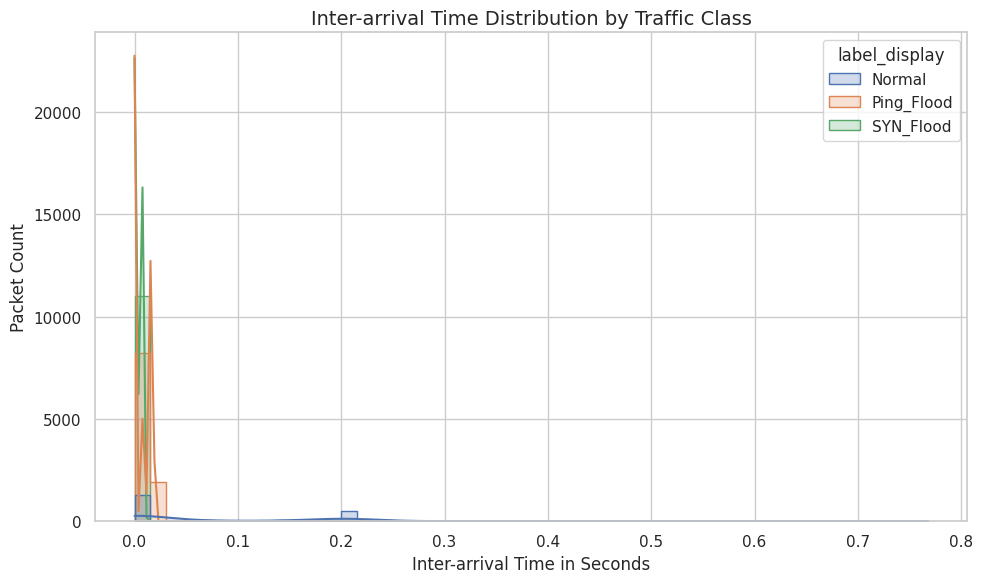

In [14]:
# Clip the x-axis at the 99th percentile so the main packet timing pattern is visible
upper_limit = df["inter_arrival"].quantile(0.99)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df[df["inter_arrival"] <= upper_limit],
    x="inter_arrival",
    hue="label_display",
    bins=50,
    kde=True,
    element="step",
)
plt.title("Inter-arrival Time Distribution by Traffic Class")
plt.xlabel("Inter-arrival Time in Seconds")
plt.ylabel("Packet Count")
plt.tight_layout()
plt.show()

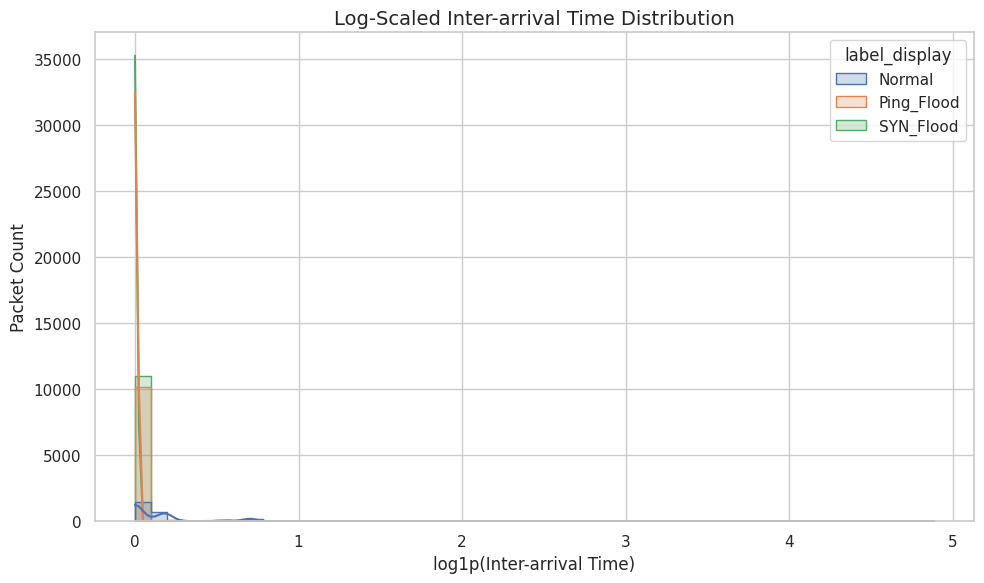

In [15]:
# Log-transform inter-arrival time to inspect long-tail timing behavior
df["inter_arrival_log1p"] = np.log1p(df["inter_arrival"])

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="inter_arrival_log1p",
    hue="label_display",
    bins=50,
    kde=True,
    element="step",
)
plt.title("Log-Scaled Inter-arrival Time Distribution")
plt.xlabel("log1p(Inter-arrival Time)")
plt.ylabel("Packet Count")
plt.tight_layout()
plt.show()

## 12. Correlation Analysis

Use a correlation heatmap to identify relationships among numeric features. Strong correlations can reveal redundant features or useful attack indicators.

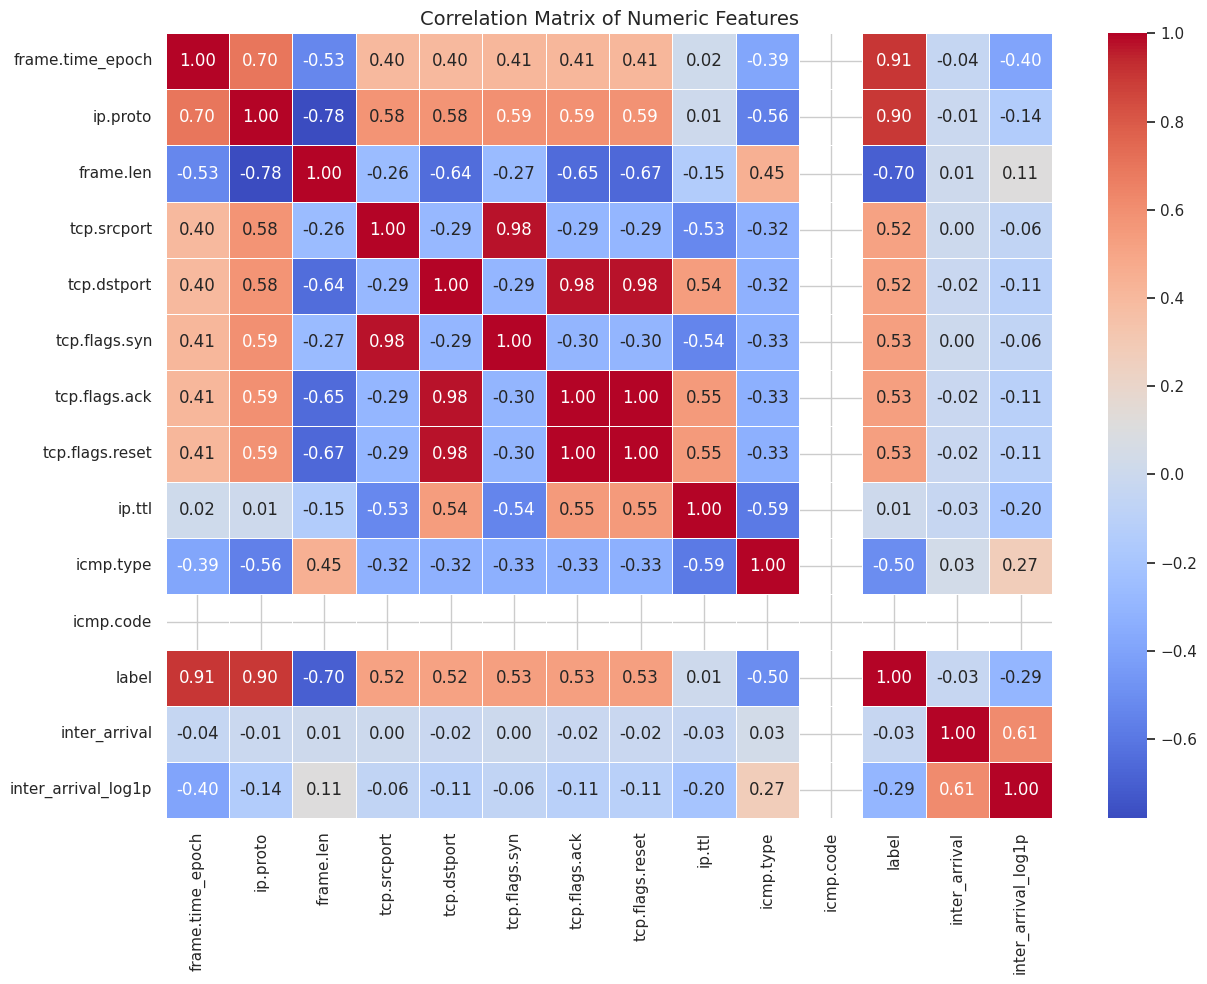

In [16]:
# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

## 13. Observations Section

### Normal vs Attack Behavior

- Normal traffic usually has more varied timing, packet sizes, protocol usage, and port behavior.
- Attack traffic often appears more repetitive because many packets are generated quickly with similar structure.
- `frame.len`, `ip.proto`, TCP flag values, ICMP fields, `ip.ttl`, and `inter_arrival` are useful features for separating traffic classes.

### Ping Flood Patterns

- Ping flood traffic is expected to be dominated by ICMP packets.
- Useful indicators include `ip.proto`, `icmp.type`, `icmp.code`, repeated packet lengths, and short `inter_arrival` times.
- Since ping floods generate repeated ICMP requests or replies, their feature distributions should be less diverse than normal traffic.

### SYN Flood Patterns

- SYN-like traffic is expected to show stronger TCP activity.
- `tcp.flags.syn` is especially important because SYN packets are used to initiate TCP connections.
- Comparing `tcp.flags.syn` and `tcp.flags.ack` helps identify whether traffic is connection-establishment heavy or includes normal bidirectional TCP responses.

In [17]:
# Quick numeric summary by class to support the observations above
important_features = [
    "frame.len",
    "ip.proto",
    "tcp.flags.syn",
    "tcp.flags.ack",
    "icmp.type",
    "icmp.code",
    "ip.ttl",
    "inter_arrival",
]

df.groupby("label_display")[important_features].mean().reindex(
    ["Normal", "Ping_Flood", "SYN_Flood"]
)

,frame.len,ip.proto,tcp.flags.syn,tcp.flags.ack,icmp.type,icmp.code,ip.ttl,inter_arrival
label_display,,,,,,,,
Normal,97.178060,0.982512,0.000000,0.000000,3.930048,0.0,94.321145,0.173560
Ping_Flood,97.962934,0.999211,0.000000,0.000000,3.996845,0.0,95.924290,0.019975
SYN_Flood,67.201179,5.993469,0.499048,0.499955,0.000000,0.0,95.892608,0.020932


## 14. Conclusion

EDA helps identify which packet-level features are likely to be useful for machine learning. By reviewing class balance, missing values, packet lengths, protocol behavior, TCP flags, timing patterns, and correlations, we can choose meaningful features and avoid training blindly.

For this project, the EDA suggests that packet length, protocol number, ICMP fields, TCP SYN/ACK flags, TTL, and inter-arrival time are important candidate features for a Random Forest attack detection model.